# 🐄 CattleWeight — Estimativa Inteligente de Peso de Gado

O **CattleWeight** é um projeto de *Machine Learning* e *AI Automation* voltado para estimar o **peso de gado com base em características físicas**, como altura, comprimento corporal e circunferência do peito.

Este projeto simula um cenário real do setor agropecuário, onde a estimativa de peso ainda é frequentemente feita de forma manual, o que pode gerar **imprecisões, inconsistências e perda de eficiência operacional**.

A solução proposta consiste em um **MVP preditivo** capaz de:

- Estimar automaticamente o peso do animal com base em dados estruturados  
- Reduzir erros humanos no processo de avaliação  
- Servir como base para automações e decisões inteligentes no negócio  
- Integrar modelos de Machine Learning com APIs e fluxos automatizados  

Além da predição, o projeto também explora o uso de **IA generativa (LLMs)** para fornecer análises interpretáveis sobre o animal, ampliando o valor da solução para usuários não técnicos.

## Descrição do projeto

### 🎯 Objetivo do Projeto

Criar um modelo de regressão que, a partir de características físicas do gado — como raça, idade, altura, comprimento corporal e circunferência do peito — estima o **peso do animal em quilogramas (kg)**.

---

### 🧠 Pipeline de Data Science

O notebook conduz as principais etapas do fluxo de ciência de dados:

1. **ETL e limpeza dos dados**  
   - Carregamento dos datasets de treino e teste  
   - Tratamento de tipos de dados e padronização das variáveis  

2. **Análise exploratória (EDA)**  
   - Visualização das distribuições das variáveis  
   - Identificação de padrões e relações com o peso  
   - Análise de variáveis categóricas (raça, sexo, cor da pelagem)

3. **Engenharia de variáveis (Feature Engineering)**  
   - Preparação das features para modelagem  
   - Encoding de variáveis categóricas  
   - Pipeline automatizado utilizando Oracle AutoMLx  

4. **Modelagem preditiva**  
   - Treinamento automatizado com Oracle AutoMLx  
   - Seleção de modelos e otimização de hiperparâmetros  
   - Comparação interna entre múltiplos algoritmos 

5. **Avaliação do modelo**  
   - Métricas como MAE (Mean Absolute Error), RMSE e R²  

6. **Exportação do modelo treinado**  
   - Serialização via `pickle` para uso pela API  

---

### 🛠️ Integração com a API

O modelo gerado neste notebook será consumido por uma **API REST**, que disponibilizará o endpoint.

## 🚀 Início do Notebook

A partir daqui, o notebook executa o fluxo completo de preparação, análise e modelagem, resultando em um modelo leve, funcional e pronto para produção no MVP do FlightOnTime.

### Imports Globais

In [ ]:
import pandas as pd
from automlx import init # type: ignore
from pprint import pprint

from loader import DataLoader

from sklearn.preprocessing import OneHotEncoder
from utils.encode_categoricals import encode_categoricals
from sklearn.model_selection import train_test_split

from utils.visualize_y import visualize_y
from utils.plot_relationships import plot_relationships
from utils.experiment_automl_pipelines import run_experiments, evaluate_experimental_models, load_experimental_models

from export.get_model_metadata import get_model_metadata
from export.export_artifact import export_model_artifact
from export.document_model import document_model
from export.test_exported_model import test_exported_model

### Preprocessamento e Carga

In [2]:
loader = DataLoader()
loader.load_data()

train_df = loader.get_train()
test_df = loader.get_test()

Dados carregados com sucesso!



#### Info

In [3]:
loader.train_info()

=> Train dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   raca                     200 non-null    category
 1   idade_meses              200 non-null    int64   
 2   altura_cm                200 non-null    float64 
 3   comprimento_corpo_cm     200 non-null    float64 
 4   circunferencia_peito_cm  200 non-null    float64 
 5   cor_pelagem              200 non-null    category
 6   sexo                     200 non-null    category
 7   peso_kg                  200 non-null    float64 
dtypes: category(3), float64(4), int64(1)
memory usage: 9.0 KB
None



In [4]:
loader.test_info()

=> Test dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   raca                     200 non-null    category
 1   idade_meses              200 non-null    int64   
 2   altura_cm                200 non-null    float64 
 3   comprimento_corpo_cm     200 non-null    float64 
 4   circunferencia_peito_cm  200 non-null    float64 
 5   cor_pelagem              200 non-null    category
 6   sexo                     200 non-null    category
dtypes: category(3), float64(3), int64(1)
memory usage: 7.4 KB
None



#### Visualizações

In [5]:
train_df.head()

,raca,idade_meses,altura_cm,comprimento_corpo_cm,circunferencia_peito_cm,cor_pelagem,sexo,peso_kg
0,Hereford,25,118.9,154.8,185.6,branca,femea,629.4
1,Angus,7,132.3,151.8,209.2,preta,femea,646.6
2,Angus,22,105.6,159.1,175.0,marrom,macho,598.5
3,Brahman,28,129.8,155.3,188.3,preta,macho,665.4
4,Nelore,9,131.0,160.0,177.2,marrom,femea,579.9


=> TRAIN dataset features:



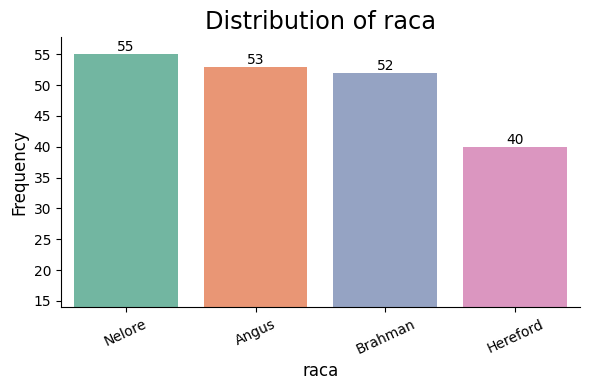

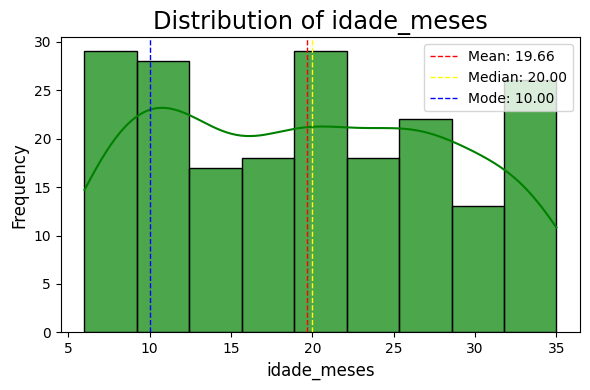

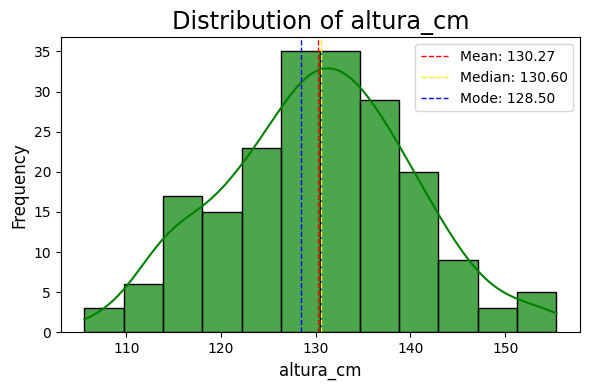

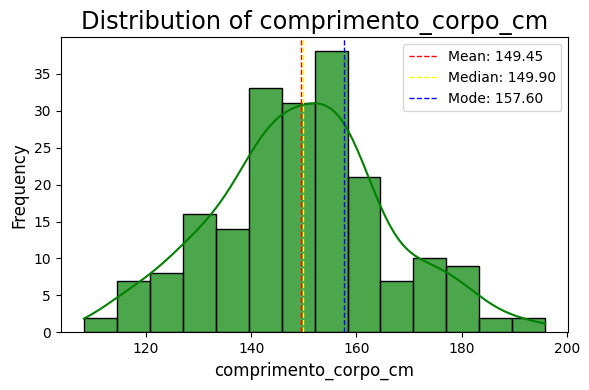

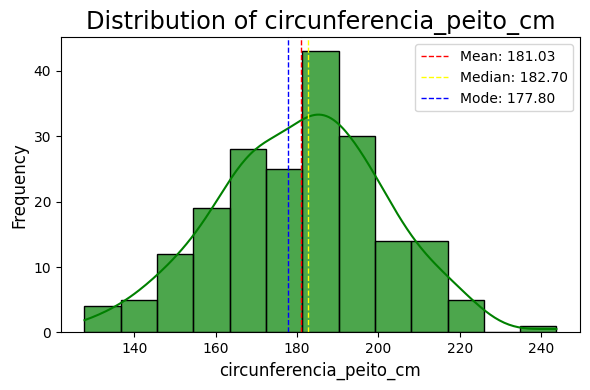

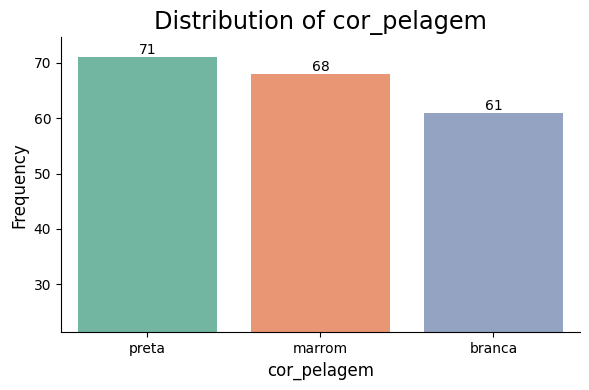

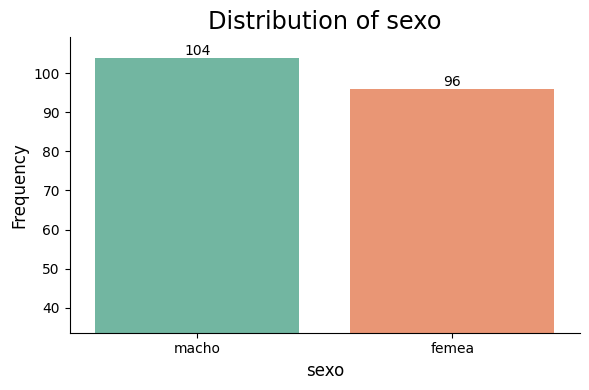

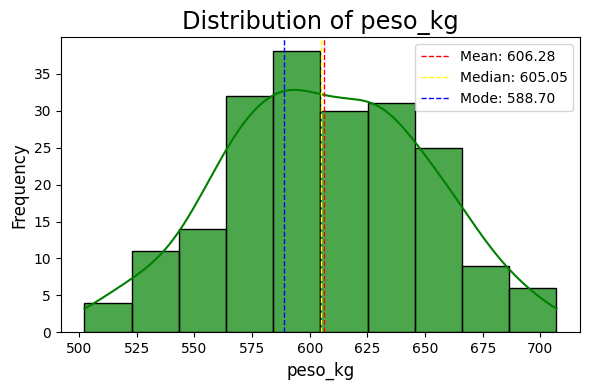

In [6]:
loader.train_features()

In [7]:
test_df.head()

,raca,idade_meses,altura_cm,comprimento_corpo_cm,circunferencia_peito_cm,cor_pelagem,sexo
0,Hereford,6,117.2,125.3,162.3,preta,macho
1,Angus,22,127.0,149.5,156.2,marrom,femea
2,Nelore,19,161.4,150.5,147.4,branca,macho
3,Brahman,28,135.9,162.8,195.2,preta,femea
4,Hereford,24,122.5,145.8,146.1,marrom,macho


=> TEST dataset features:



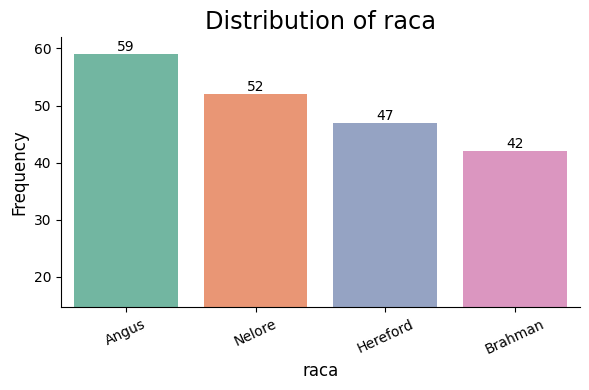

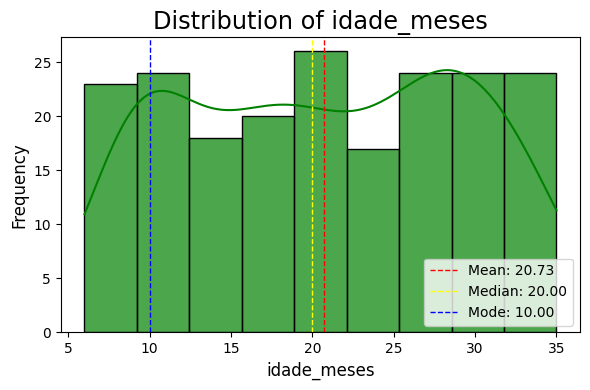

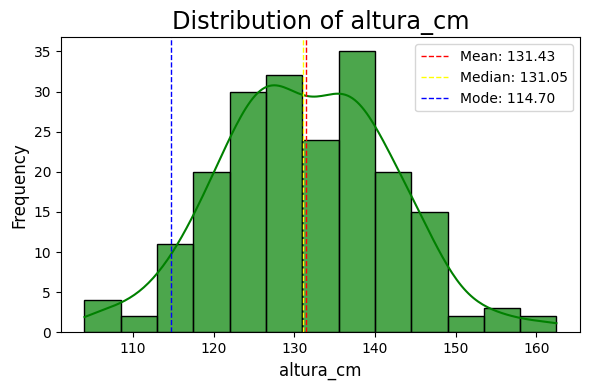

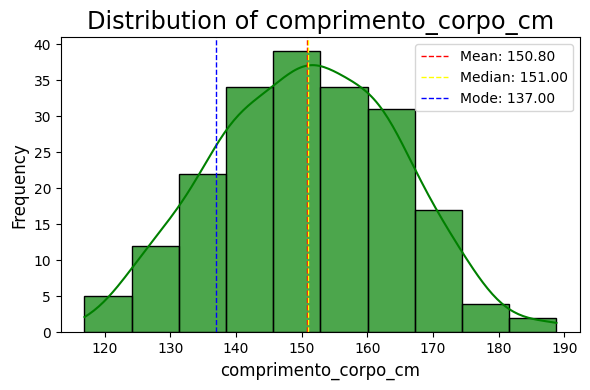

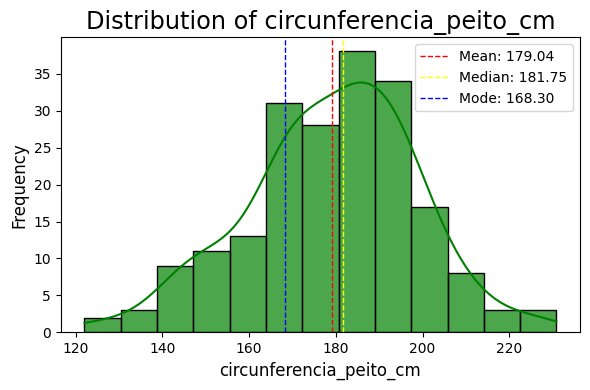

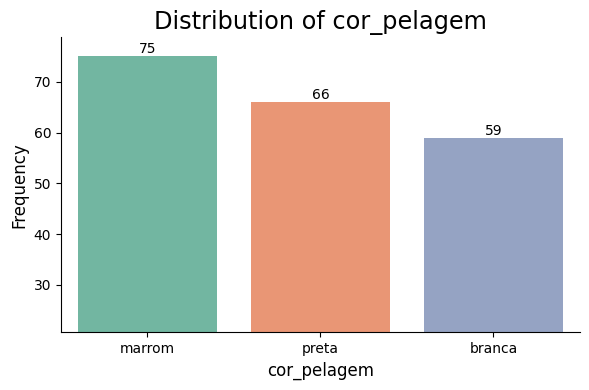

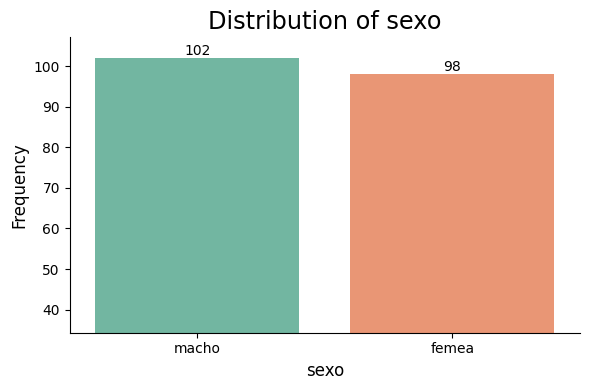

In [8]:
loader.test_features()

### Visualizando (Y)

Aqui analisamos a distribuição do peso do gado no histórico de cabeças observadas.  

- Os dados são balanceados  
- A distrubição faz sentido e não dá sinais de inconsistências  
- Nenhum outlier presente. Dataset perfeito.

peso_kg
588.7    3
565.3    2
570.5    2
558.7    2
523.8    2
        ..
636.7    1
542.8    1
602.9    1
608.8    1
618.7    1
Name: count, Length: 190, dtype: int64

peso_kg
588.7    0.015
565.3    0.010
570.5    0.010
558.7    0.010
523.8    0.010
         ...  
636.7    0.005
542.8    0.005
602.9    0.005
608.8    0.005
618.7    0.005
Name: proportion, Length: 190, dtype: float64


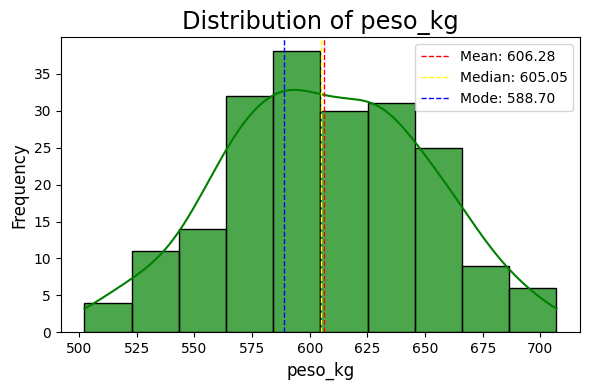

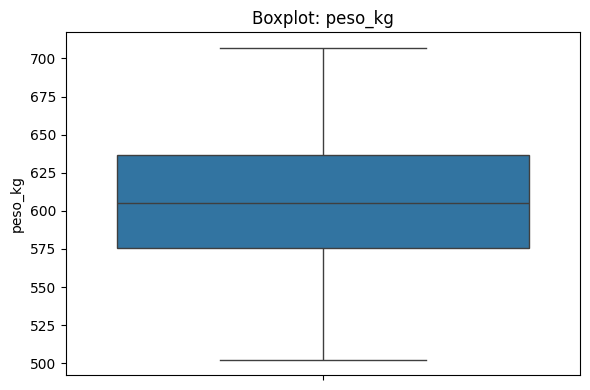

In [9]:
visualize_y(train_df, y_col_name='peso_kg')

### Encoding

In [10]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
categorical_cols = ["raca", "cor_pelagem", "sexo"]

train_df_encoded, test_df_encoded = encode_categoricals(train_df, test_df, encoder=encoder, categorical_cols=categorical_cols)

#### Analisando correlações

Aqui analisamos as correlações para compreender quais variáveis mais influenciam o peso do gado.

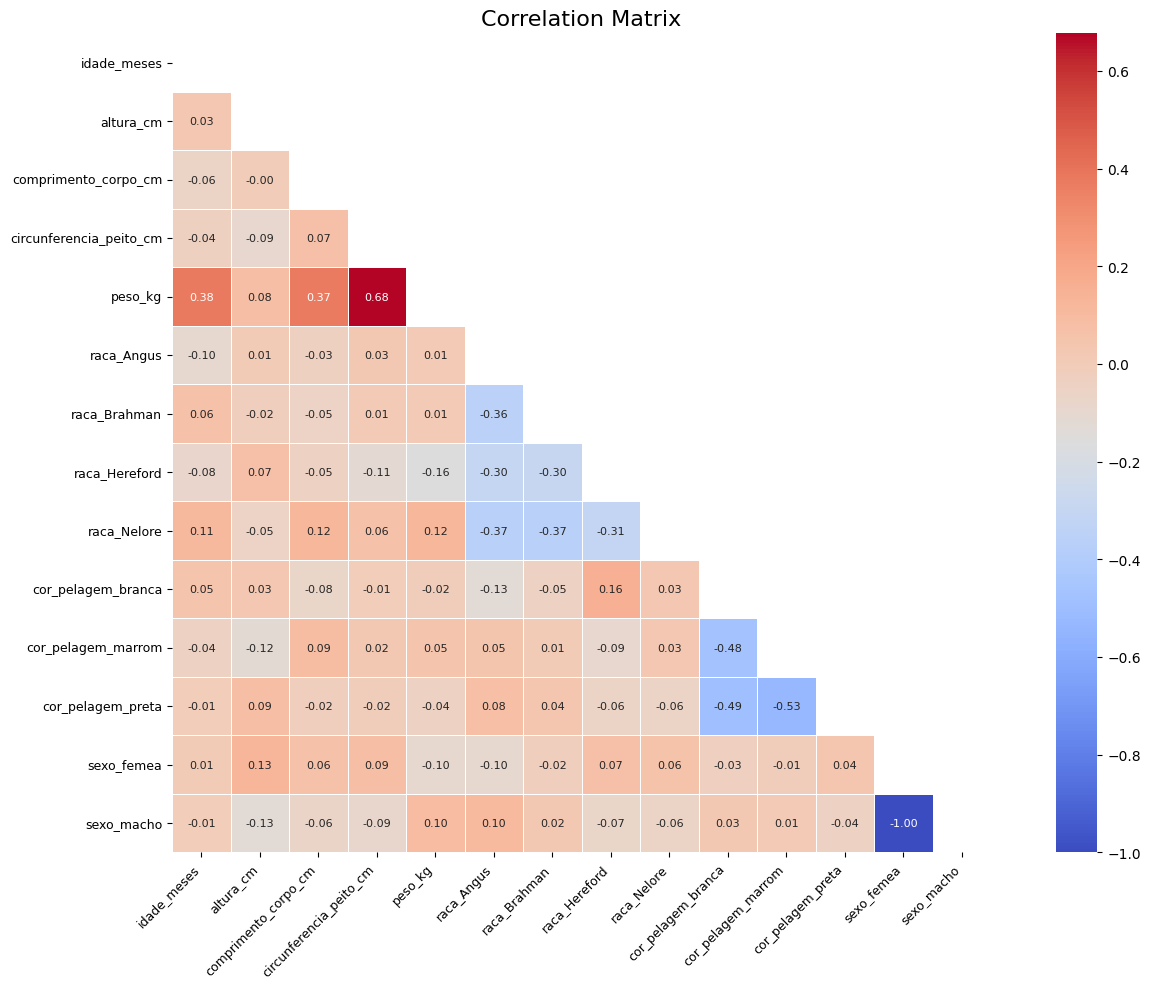

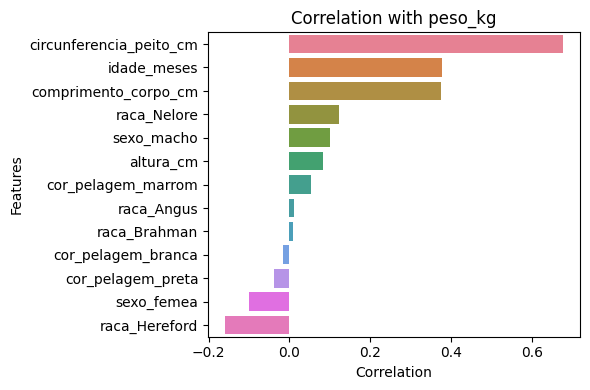

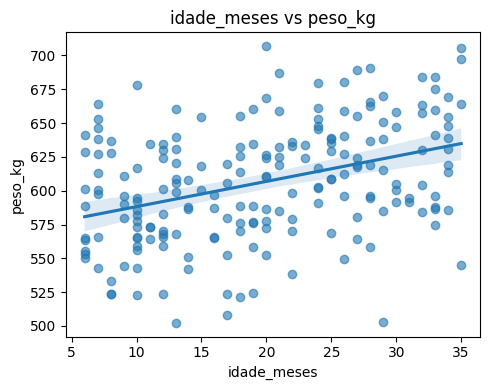

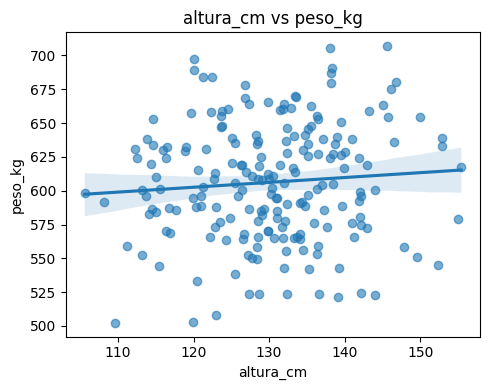

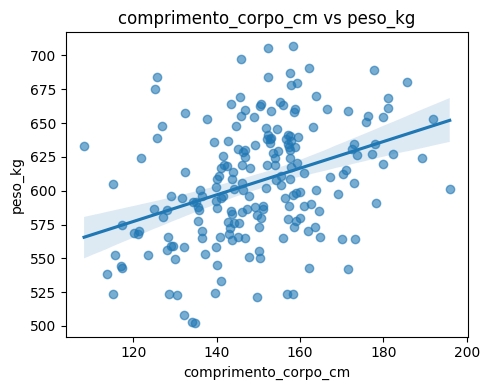

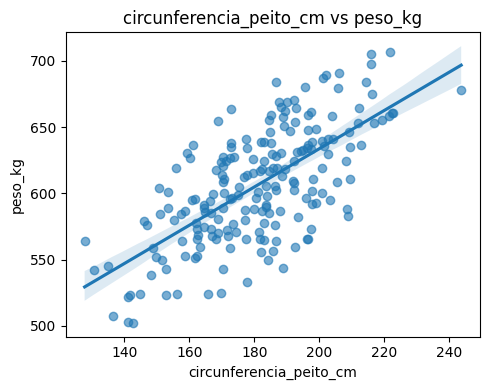

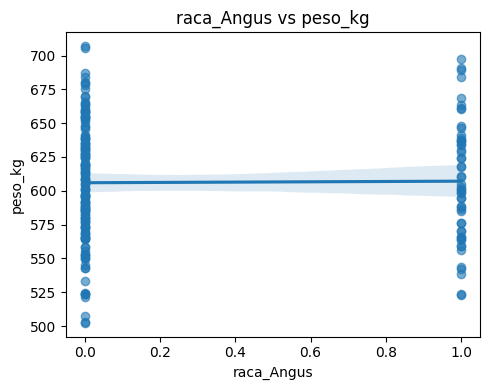

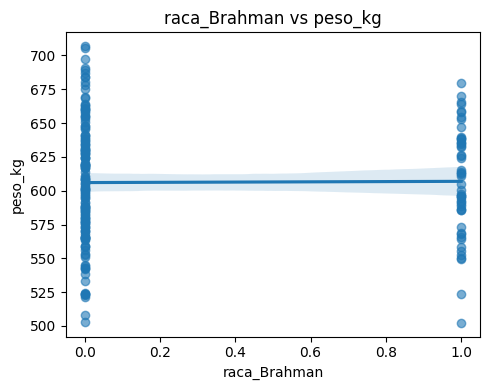

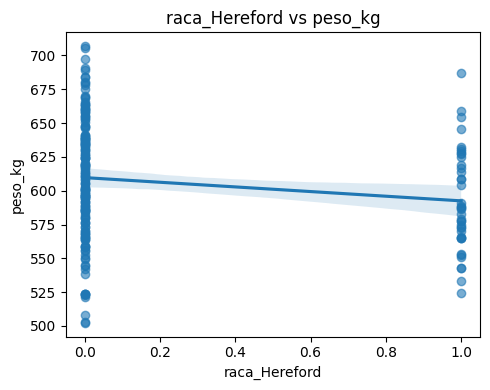

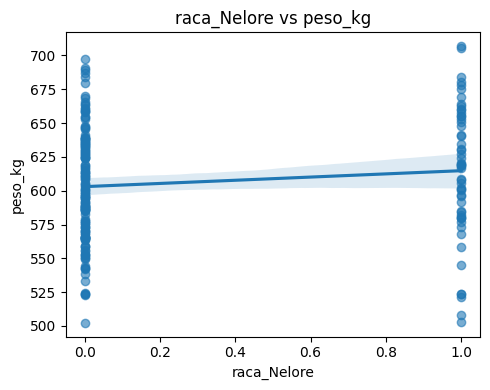

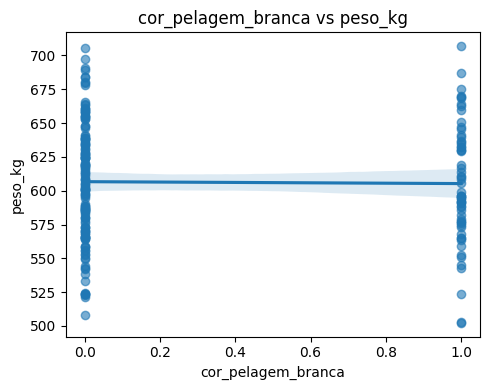

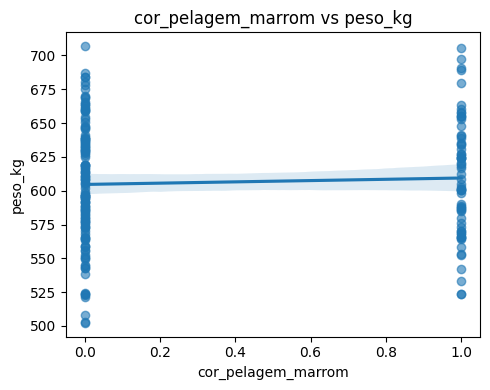

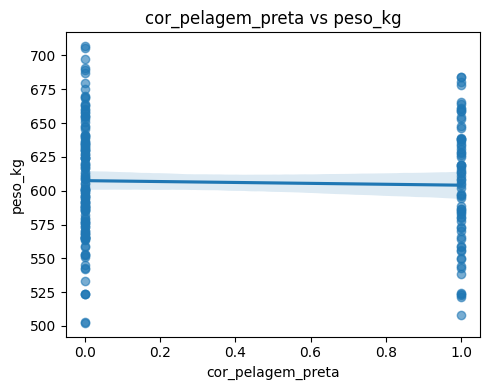

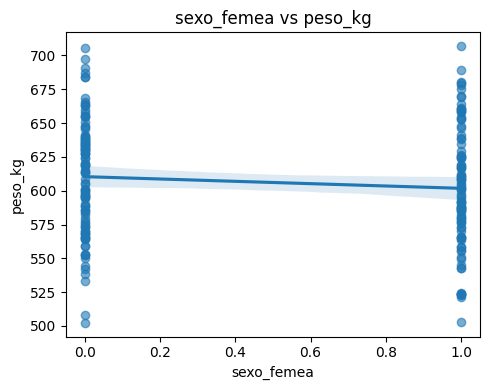

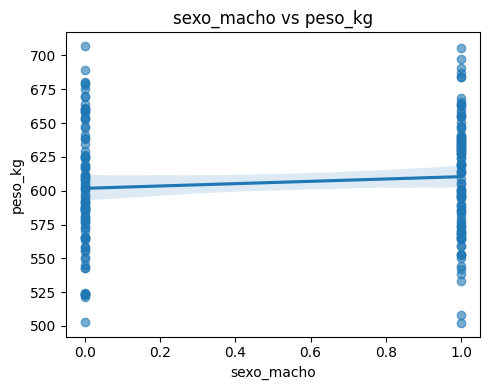

In [11]:
plot_relationships(train_df_encoded, target='peso_kg')

### Separando X e Y

Aqui separaremos as features (X) da variável alvo (Y).

In [12]:
X = train_df_encoded.drop(columns=["peso_kg"])
y = train_df_encoded["peso_kg"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((160, 13), (40, 13), (160,), (40,))

In [13]:
X_train.head()

,idade_meses,altura_cm,comprimento_corpo_cm,circunferencia_peito_cm,raca_Angus,raca_Brahman,raca_Hereford,raca_Nelore,cor_pelagem_branca,cor_pelagem_marrom,cor_pelagem_preta,sexo_femea,sexo_macho
79,7,141.2,128.4,177.5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
197,6,140.1,146.2,186.8,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
38,8,136.6,128.5,156.3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
24,16,135.1,158.2,180.6,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
122,27,138.1,121.8,182.9,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [14]:
y_val.head()

95     573.1
15     610.6
30     585.6
158    627.3
128    633.4
Name: peso_kg, dtype: float64

### Modelagem

Para o processo de modelagem, foi decidido usar a moderna biblioteca [Oracle AutoMLx](https://docs.oracle.com/en-us/iaas/tools/automlx/latest/latest/index.html), que automatiza os processos de `Seleção de Algoritmo`, `Sampling Adaptativo`, `Seleção de Features` e `Ajuste de Hiperparâmetros`, resultando num processo facilitado e com melhores métricas no modelo final.  

In [15]:
init(engine='local')

#### Experimentação - Avaliação de Pipelines

Nesta etapa, utilizamos o Oracle AutoMLx para treinar modelos de regressão com o objetivo de estimar o peso do gado com base em características físicas.

Dado que o dataset apresenta uma relação aproximadamente linear entre as variáveis, os experimentos foram simplificados para avaliar:

- A capacidade de modelos lineares em capturar o padrão dos dados  
- O ganho potencial ao utilizar modelos não lineares  
- O impacto do tuning automático fornecido pelo AutoMLx  

**NOTA:**  
- É esperado que o modelo não linear performe muito mal, no entanto experimentaremos para provar a hipótese.  

---

##### 1. Baseline Linear — Regressão Linear

Inicialmente, treinamos um modelo de regressão linear como baseline.

Este experimento tem como objetivo:
- Servir como referência simples e interpretável  
- Avaliar se a relação linear dos dados é suficiente para boa performance  

---

##### 2. Modelo Não Linear — LightGBM Regressor

Em seguida, utilizamos um modelo baseado em árvores (LightGBM Regressor).

O objetivo é:
- Capturar possíveis não linearidades e interações entre variáveis  
- Comparar com o baseline linear  

---

##### 3. AutoML com Tuning

Por fim, utilizamos o AutoMLx com tuning automático ativado.

Este experimento busca:
- Avaliar ganhos com otimização de hiperparâmetros  
- Validar o uso de automação no pipeline  

---

Ao final, comparamos os modelos com base em métricas de regressão, buscando o melhor equilíbrio entre simplicidade e performance.

In [16]:
PIPELINE_CONFIGS = {
    "01_linear_baseline": {
        "task": "regression",
        "model_list": ["LinearRegression"],
        "preprocessing": True,
    },

    "02_lgbm_baseline": {
        "task": "regression",
        "model_list": ["LGBMRegressor"],
        "n_algos_tuned": 1,
        "max_tuning_trials": 1,
    },

    "03_automl_tuned": {
        "task": "regression",
        "max_tuning_trials": 5,
    },
}

##### Realizando experimentação

Esta funcionalidade permite realizar a experimentação de pipelines conforme as configurações contidas no dicionário `PIPELINE_CONFIGS`. Após a experimentação, os modelos são salvos em ./models/experimental_models.  

In [17]:
# Código comentado por segurança
# Descomente a linha abaixo para executar a experimentação dos pipelines AutoMLx

experimental_models = run_experiments(pipeline_configs=PIPELINE_CONFIGS, X_train=X_train, y_train=y_train)


🚀 Running experiment: 01_linear_baseline

[2026-03-22 22:36:16,281] [automlx.interface] Dataset shape: (160,13)
[2026-03-22 22:36:16,406] [automlx.data_transform] Running preprocessing. Number of features: 14
[2026-03-22 22:36:16,631] [automlx.data_transform] Preprocessing completed. Took 0.225 secs
[2026-03-22 22:36:16,657] [automlx.process] Running Model Generation
[2026-03-22 22:36:16,692] [automlx.process] Model Generation completed.
[2026-03-22 22:36:16,736] [automlx.model_selection] Running Model Selection
[2026-03-22 22:36:16,737] [automlx.trials] Fewer models (1) than top_k (1) provided, skipping...
[2026-03-22 22:36:16,766] [automlx.adaptive_sampling] Running Adaptive Sampling. Dataset shape: (160,14).
[2026-03-22 22:36:16,795] [automlx.adaptive_sampling] Adaptive Sampling: top_limit: 128 < bottom_limit: 1000,
sampling process will be skipped
[2026-03-22 22:36:16,797] [automlx.adaptive_sampling] Adaptive Sampling: top_limit: 32 < bottom_limit: 1000,
sampling process will be s

##### Carregar Modelos Experimentais

Esta funcionalidade permite carregar modelos experimentais previamente treinados e salvos a partir de um dicionário `PIPELINE_CONFIGS`.

In [18]:
experimental_models = load_experimental_models(PIPELINE_CONFIGS)

Carregando modelos experimentais...

🔄 Carregando modelo: 01_linear_baseline
🔄 Carregando modelo: 02_lgbm_baseline
🔄 Carregando modelo: 03_automl_tuned

🏁 Modelos carregados com sucesso!


##### Avaliando Modelos Experimentais


📊 Experiment results: 01_linear_baseline

=> Métricas de Regressão:

MAE  (Mean Absolute Error): 18.62
RMSE (Root Mean Squared Error): 22.14
R²   (Coeficiente de Determinação): 0.6031



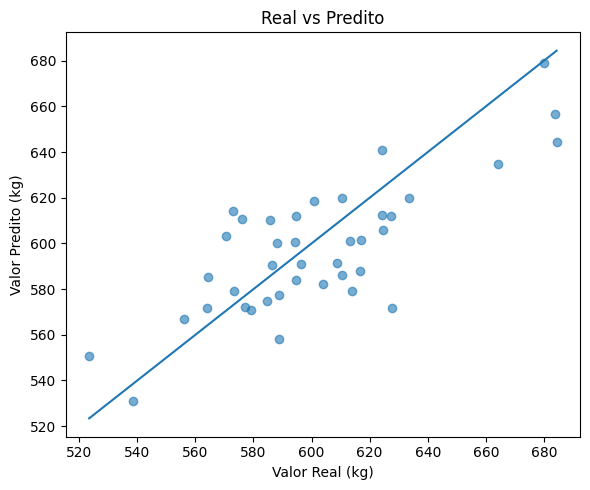

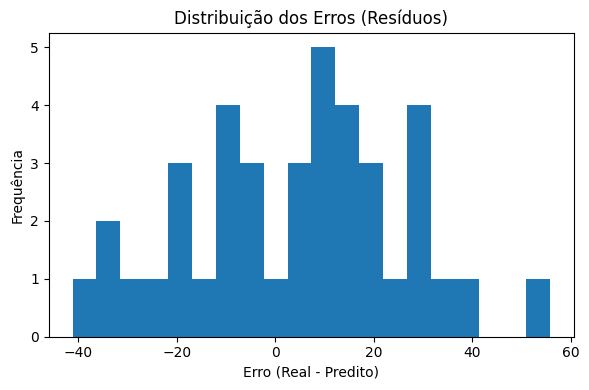


📊 Experiment results: 02_lgbm_baseline

=> Métricas de Regressão:

MAE  (Mean Absolute Error): 68.89
RMSE (Root Mean Squared Error): 73.09
R²   (Coeficiente de Determinação): -3.3236



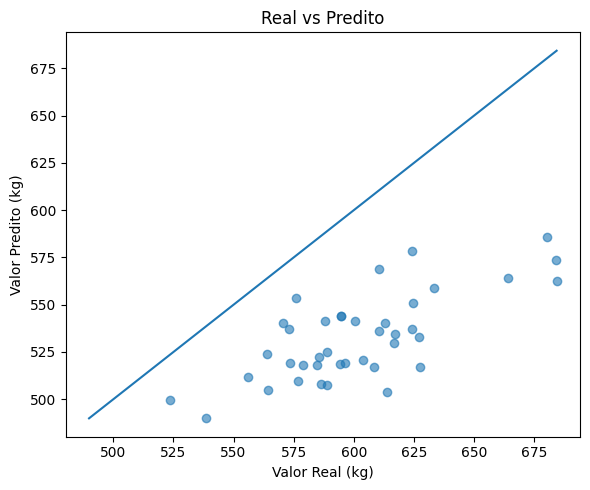

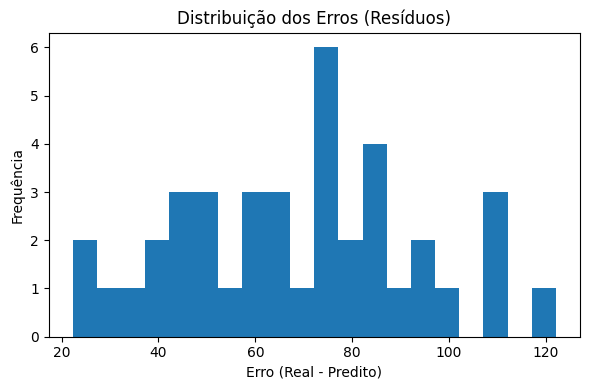


📊 Experiment results: 03_automl_tuned

=> Métricas de Regressão:

MAE  (Mean Absolute Error): 18.62
RMSE (Root Mean Squared Error): 22.14
R²   (Coeficiente de Determinação): 0.6031



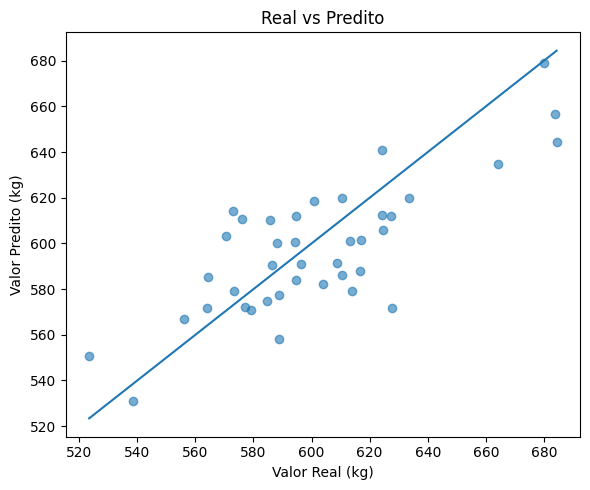

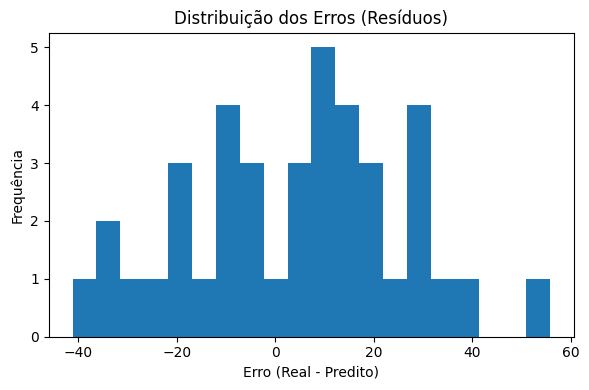

In [19]:
evaluate_experimental_models(
    experimental_models=experimental_models,
    X_test=X_val,
    y_test=y_val,
)

##### Insights

**📊 Comparação de Modelos**

| Modelo                | MAE ↓ (kg) | RMSE ↓ (kg) | R² ↑    |
|----------------------|-----------|------------|--------|
| Regressão Linear     | 18.62     | 22.14      | 0.6031 |
| LightGBM (baseline)  | 68.89     | 73.09      | -3.3236 |
| AutoML (tuned)       | 18.62     | 22.14      | 0.6031 |

Observa-se que a Regressão Linear e o AutoML apresentaram desempenho idêntico e ligeiramente superior à versão anterior, enquanto o modelo baseado em árvores (LightGBM) manteve performance significativamente inferior, indicando baixa capacidade de generalização neste contexto.

Os experimentos realizados fornecem uma visão clara sobre a natureza do problema e sobre as escolhas mais adequadas de modelagem.

- Em primeiro lugar, o modelo de Regressão Linear apresentou desempenho consistente, com MAE em torno de 19 kg e R² próximo de 0.59. Esse resultado indica que uma parcela significativa da variabilidade do peso pode ser explicada por relações lineares entre as variáveis físicas do animal, confirmando a hipótese inicial sobre a estrutura do dataset.

- Em contraste, o modelo baseado em árvores (LightGBM) apresentou desempenho significativamente inferior, com erro elevado e R² negativo. Esse comportamento confirma a hipótese de que, dado o tamanho reduzido do dataset e a natureza aproximadamente linear dos dados, modelos mais complexos não conseguem generalizar bem, possivelmente sofrendo com overfitting ou instabilidade.

- O experimento com AutoMLx e tuning automático não trouxe ganhos em relação ao baseline linear, reproduzindo exatamente os mesmos resultados. Isso reforça que, para este problema específico, a complexidade adicional de otimização de hiperparâmetros não se traduz em melhoria de performance.

- De forma geral, os resultados indicam que o problema é relativamente simples do ponto de vista estrutural, sendo bem capturado por modelos lineares. A utilização de modelos mais sofisticados não se justifica neste contexto, tanto do ponto de vista de performance quanto de custo computacional.

- Assim, a Regressão Linear se mostra a melhor escolha, oferecendo um bom equilíbrio entre precisão, interpretabilidade e simplicidade de implementação.

### Melhor Modelo

Em nossos experimentos, encontramos que o melhor modelo experimental foi o modelo `01_linear_baseline`, com um **R²** de **~0.6031**, o qual utilizaremos em produção.

In [20]:
best_estimator = experimental_models['01_linear_baseline']

#### Testando inferência

In [21]:
pred = best_estimator.predict(X_val.head())
pred = pd.Series(pred, name='predicted_peso_kg')

pred

0    614.273071
1    620.074524
2    610.188660
3    612.054810
4    619.836182
Name: predicted_peso_kg, dtype: float32

### Exportação do Modelo

Aqui exportamos o melhor model artifact em formato `.pkl` para uso em inferência.  

Um model artifact é um `dict` contendo:

- model : object  
    - Modelo treinado.  
- encoder : object  
    - Encoder ajustado (OneHotEncoder).  
- categorical_cols : list  
    - Lista de colunas categóricas utilizadas no encoding.  

In [29]:
model_metadata = get_model_metadata(best_estimator, original_features=list(test_df_encoded.columns))
pprint(model_metadata)

{'features': ['altura_cm',
              'circunferencia_peito_cm',
              'comprimento_corpo_cm',
              'cor_pelagem_marrom',
              'idade_meses',
              'raca_Brahman',
              'raca_Hereford',
              'sexo_femea'],
 'features_raw': ['idade_meses',
                  'altura_cm',
                  'comprimento_corpo_cm',
                  'circunferencia_peito_cm',
                  'raca_Angus',
                  'raca_Brahman',
                  'raca_Hereford',
                  'raca_Nelore',
                  'cor_pelagem_branca',
                  'cor_pelagem_marrom',
                  'cor_pelagem_preta',
                  'sexo_femea',
                  'sexo_macho'],
 'model': 'LinearRegression',
 'model_type': 'AutoRegressor',
 'score_metric': None,
 'specifications': {},
 'training_time': None}


#### Exportando

In [ ]:
model_artifact_filename = export_model_artifact(
    model=best_estimator,
    encoder=encoder,
    categorical_cols=["raca", "cor_pelagem", "sexo"],
    filename="cattle_weight_model_artifact",
    timestamp=True
)

Artifact:

  model: <automlx._interface.regressor.AutoRegressor object at 0x715aa6044e60>
  encoder: OneHotEncoder(handle_unknown='ignore', sparse_output=False)
  categorical_cols: ['raca', 'cor_pelagem', 'sexo']
  created_at: 2026-03-22T22:39:10.130221
  version: cattle_weight_model_artifact_v1_20260322_223910

📦 Artifact salvo com sucesso:
   → ./models/cattle_weight_model_artifact_v1_20260322_223910.pkl



#### Exportando documentação

In [24]:
document_model(best_estimator, model_name=model_metadata['model'], model_metadata=model_metadata, model_features=model_metadata['features_raw'], x=X_val, y=y_val, output_format='.md', timestamp=True)

📁 Arquivo salvo com sucesso:
   → ./models/model_documentation_LinearRegression_20260322_223910.md


#### Testando o modelo exportado

In [25]:
test_exported_model(model_artifact_filename, X_val.head())


📊 Testing model: cattle_weight_model_v1_20260322_223910.pkl

Test data columns:
Index(['idade_meses', 'altura_cm', 'comprimento_corpo_cm',
       'circunferencia_peito_cm', 'raca_Angus', 'raca_Brahman',
       'raca_Hereford', 'raca_Nelore', 'cor_pelagem_branca',
       'cor_pelagem_marrom', 'cor_pelagem_preta', 'sexo_femea', 'sexo_macho'],
      dtype='object')

Predictions on first 10 samples:

0    614.273071
1    620.074524
2    610.188660
3    612.054810
4    619.836182
Name: predicted_peso_kg, dtype: float32


## Apêndice: Estudo do Processo de AutoML

Nesta seção analisamos o processo de otimização executado pelo AutoMLx de forma a compreender melhor o processo de modelagem que ele executa.  

Para um estudo mais aprofundado da biblioteca, utilizaremos o melhor estimador `01_linear_baseline` gerado anteriormente para podermos observar o processo de **Seleção de Features**.  
Neste estudo não pudemos nos aprofundar nos processos de **Seleção de Algoritmo**, **Sampling Adaptativo** e **Model Tuning** devido à simplicidade do dataset e do problema.  

Para mais informações acesse:
- [Documentação do AutoMLx](https://docs.oracle.com/en-us/iaas/tools/automlx/latest/latest/index.html)  
- [Demo: AutoMLx Classification](https://github.com/oracle-samples/automlx/blob/main/demos/OracleAutoMLx_Classification.ipynb)

In [26]:
from utils.plot_automl_results import plot_feature_selection

### Sumário

Sumário dos experimentos executados pelo AutoMLx.

In [27]:
best_estimator.print_summary()

""
"(160, 13)"
None
"RepeatedKFoldSplit(Shuffle=True, Seed=7, number of splits=5, number of repeats=3)"
neg_mean_squared_error
LinearRegression
{}
25.3.1
"3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:16:04) [GCC 11.2.0]"


Step,# Samples,# Features,Algorithm,Hyperparameters,Score (neg_mean_squared_error),All Metrics,Runtime (Seconds),Memory Usage (GB),Finished
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",8,LinearRegression,{},-384.3185,{'neg_mean_squared_error': -384.3185340284134},2.1778,0.2332,Sun Mar 22 22:36:38 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",10,LinearRegression,{},-384.533,{'neg_mean_squared_error': -384.53302192093236},2.6360,0.2333,Sun Mar 22 22:36:35 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 14: 128, 13: 128, 15: 128}",10,LinearRegression,{},-384.8026,{'neg_mean_squared_error': -384.80264588099055},6.5968,0.2332,Sun Mar 22 22:36:28 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",10,LinearRegression,{},-385.8597,{'neg_mean_squared_error': -385.85974577873833},1.8161,0.2331,Sun Mar 22 22:36:36 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",10,LinearRegression,{},-386.7269,{'neg_mean_squared_error': -386.7269223575583},5.3092,0.2331,Sun Mar 22 22:36:30 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",12,LinearRegression,{},-386.727,{'neg_mean_squared_error': -386.72697576504913},3.7717,0.2354,Sun Mar 22 22:36:22 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",12,LinearRegression,{},-386.9987,{'neg_mean_squared_error': -386.9987122457709},3.3729,0.2332,Sun Mar 22 22:36:32 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",12,LinearRegression,{},-387.1794,{'neg_mean_squared_error': -387.1794404786458},14.8437,0.2404,Sun Mar 22 22:36:20 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",8,LinearRegression,{},-442.3029,{'neg_mean_squared_error': -442.3028629201412},2.1507,0.2332,Sun Mar 22 22:36:40 2026
Feature Selection,"{1: 128, 2: 128, 3: 128, 4: 128, 5: 128, 6: 128, 7: 128, 8: 128, 9: 128, 10: 128, 11: 128, 12: 128, 13: 128, 14: 128, 15: 128}",6,LinearRegression,{},-442.9075,{'neg_mean_squared_error': -442.90747508445384},2.0936,0.2331,Sun Mar 22 22:36:39 2026


### Visualizações

Cada experimento (`trial`) nos gráficos abaixo é uma linha em um dataframe que contém:  
Algoritmo, Número de Amostras, Número de Features, Hiperparâmetros, Score, Tempo de Execução, Uso de Memória e Etapa.  

Para saber mais:
- [Acesse as funções](./utils/plot_automl_results.py)  

- Utilize o método `help()` para cada função.  
    <small>Exemplo: "help(plot_adaptive_sampling)"</small>

#### Seleção de Features

Processo de seleção de features do AutoMLx.
- `Y`: Métrica
- `X`: Número de features

Features selected: ['altura_cm', 'circunferencia_peito_cm', 'comprimento_corpo_cm', 'cor_pelagem_marrom', 'idade_meses', 'raca_Brahman', 'raca_Hereford', 'sexo_femea']
Features dropped: ['peso_kg', 'raca_Angus', 'raca_Nelore', 'cor_pelagem_branca', 'cor_pelagem_preta', 'sexo_macho']


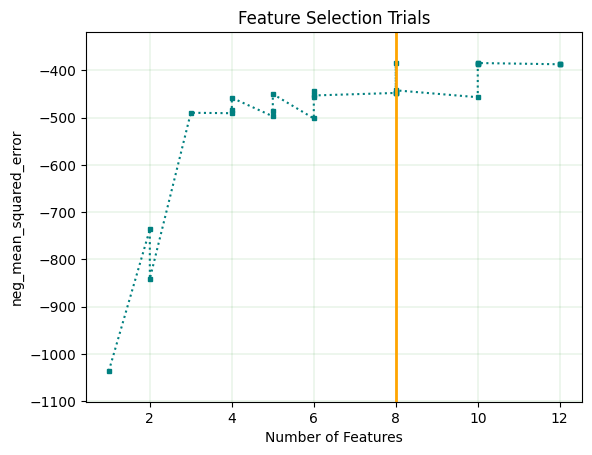

In [28]:
plot_feature_selection(best_estimator, train_df_encoded)

#### a